In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [16]:
# Load in the data
SAFB = pd.read_csv('/project/PlatigLab/users/reece/Yogi_Project/SAFB_K562_SE.MATS.JunctionCountOnly.txt', sep='\t')
IGF_K562 = pd.read_csv('/project/PlatigLab/users/reece/Yogi_Project/IGF_K562_SE.MATS.JunctionCountOnly.txt', sep='\t')
IGF_HEPG2 = pd.read_csv('/project/PlatigLab/users/reece/Yogi_Project/IGF_HEPG2_SE.MATS.JunctionCountOnly.txt', sep='\t')

In [22]:
# Create a table and drop unnecessary columns
# Only need FDR, geneSymbol, ID, PValue, FDR, IncLevelDifference

SAFB_filtered = SAFB[["FDR", "geneSymbol", "ID", "PValue", "IncLevelDifference"]]

IGF_K562_filtered = IGF_K562[["FDR", "geneSymbol", "ID", "PValue", "IncLevelDifference"]]

IGF_HEPG2_filtered = IGF_HEPG2[["FDR", "geneSymbol", "ID", "PValue", "IncLevelDifference"]]

In [23]:
# Plotting stuff

def assign_color(row):
    if row["FDR"] >= 0.05 or abs(row["IncLevelDifference"]) < 0.05:
        return "gray"
    elif row["IncLevelDifference"] >= 0.05:
        return "red"
    elif row["IncLevelDifference"] <= -0.05:
        return "blue"
    else:
        return "gray"  # fallback


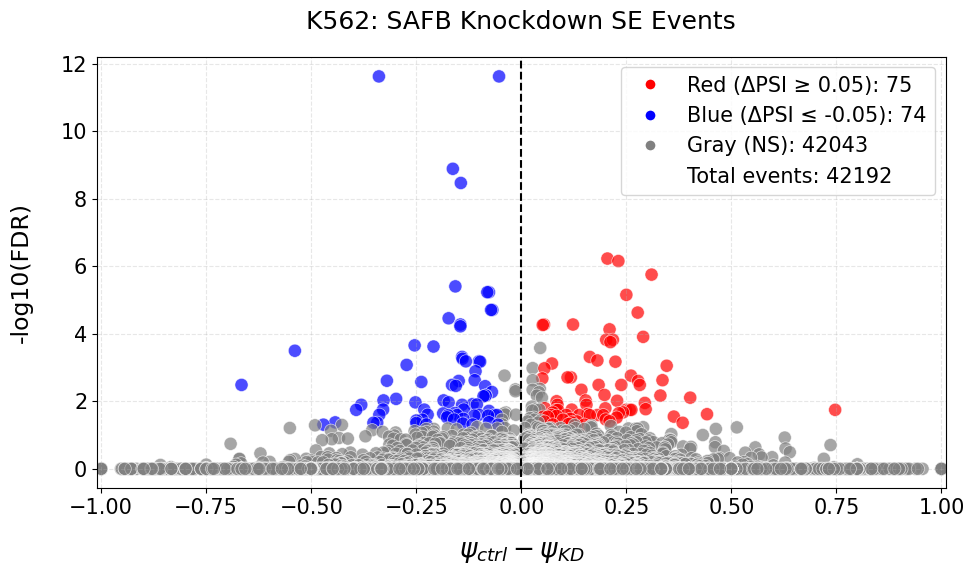

In [24]:
# Create a volcano plot


# DPSI conversion
SAFB_filtered = SAFB_filtered.assign(
    IncLevelDifference = SAFB_filtered["IncLevelDifference"] * -1
)

# -log10 FDR conversion

# Find the smallest non-zero FDR value
min_nonzero_fdr = SAFB_filtered.loc[SAFB_filtered["FDR"] > 0, "FDR"].min()

# Replace zeros with min
SAFB_filtered["FDR_safe"] = SAFB_filtered["FDR"].replace(0, min_nonzero_fdr)

# Calculate -log10(FDR)
SAFB_filtered["neg_log10_FDR"] = -np.log10(SAFB_filtered["FDR_safe"])


# Colors and plots

SAFB_filtered["color"] = SAFB_filtered.apply(assign_color, axis=1)

counts = SAFB_filtered["color"].value_counts().to_dict()
num_points = len(SAFB_filtered)

# Parameter for global font size
plt.rcParams.update({'font.size': 15})

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    SAFB_filtered["IncLevelDifference"],
    SAFB_filtered["neg_log10_FDR"],
    c=SAFB_filtered["color"],
    alpha=0.7,
    edgecolors='w',
    linewidth=0.5,
    s = 90
)

# Setting x axis
xlim = max(abs(min(SAFB_filtered["IncLevelDifference"])), abs(max(SAFB_filtered["IncLevelDifference"])))
plt.xlim(-xlim - 0.01, xlim + 0.01)  # symmetric around zero
plt.axvline(0, color="black", linestyle="--")  # reference line at zero

# Legend
legend_labels = [
    f"Red (ΔPSI ≥ 0.05): {counts.get('red', 0)}",
    f"Blue (ΔPSI ≤ -0.05): {counts.get('blue', 0)}",
    f"Gray (NS): {counts.get('gray', 0)}",
    f"Total events: {num_points}"
]

# Create dummy handles for legend colors
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker='o', color='w', label=legend_labels[0],
           markerfacecolor='red', markersize=8),
    Line2D([0], [0], marker='o', color='w', label=legend_labels[1],
           markerfacecolor='blue', markersize=8),
    Line2D([0], [0], marker='o', color='w', label=legend_labels[2],
           markerfacecolor='gray', markersize=8),
    Line2D([0], [0], color='w', label=legend_labels[3])  # total count (no color)
]

plt.legend(handles=handles, loc="best")

# Labels
plt.xlabel("$\\psi_{ctrl} - \\psi_{KD}$", fontsize = 19, labelpad = 15)
plt.ylabel("-log10(FDR)", fontsize = 17, labelpad = 20)
plt.title(f"K562: SAFB Knockdown SE Events", pad=20)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

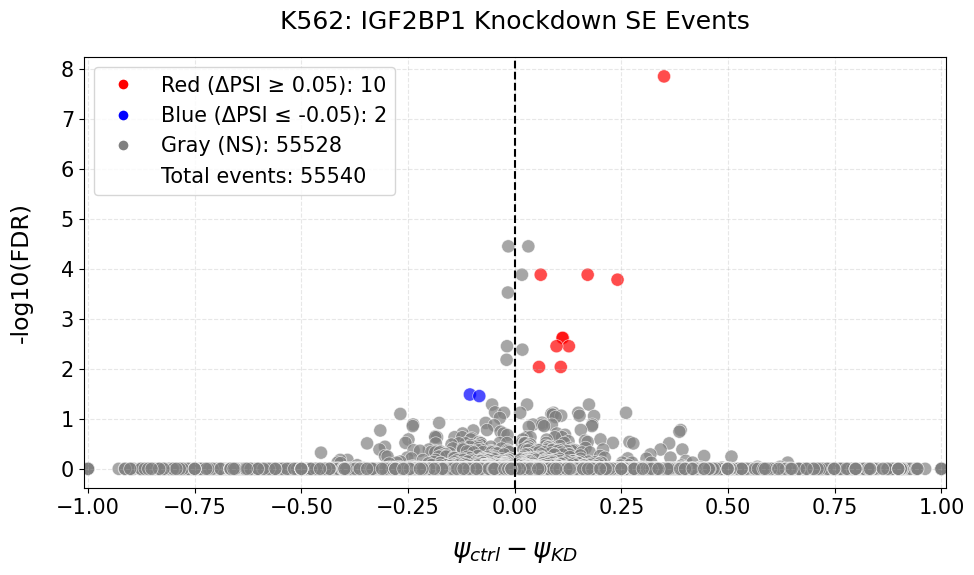

In [25]:
# Create a volcano plot


# DPSI conversion
IGF_K562_filtered = IGF_K562_filtered.assign(
    IncLevelDifference = IGF_K562_filtered["IncLevelDifference"] * -1
)

# -log10 FDR conversion

# Find the smallest non-zero FDR value
min_nonzero_fdr = IGF_K562_filtered.loc[IGF_K562_filtered["FDR"] > 0, "FDR"].min()

# Replace zeros with min
IGF_K562_filtered["FDR_safe"] = IGF_K562_filtered["FDR"].replace(0, min_nonzero_fdr)

# Calculate -log10(FDR)
IGF_K562_filtered["neg_log10_FDR"] = -np.log10(IGF_K562_filtered["FDR_safe"])


# Colors and plots

IGF_K562_filtered["color"] = IGF_K562_filtered.apply(assign_color, axis=1)

counts = IGF_K562_filtered["color"].value_counts().to_dict()
num_points = len(IGF_K562_filtered)

# Parameter for global font size
plt.rcParams.update({'font.size': 15})

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    IGF_K562_filtered["IncLevelDifference"],
    IGF_K562_filtered["neg_log10_FDR"],
    c=IGF_K562_filtered["color"],
    alpha=0.7,
    edgecolors='w',
    linewidth=0.5,
    s = 90
)

# Setting x axis
xlim = max(abs(min(IGF_K562_filtered["IncLevelDifference"])), abs(max(IGF_K562_filtered["IncLevelDifference"])))
plt.xlim(-xlim - 0.01, xlim + 0.01)  # symmetric around zero
plt.axvline(0, color="black", linestyle="--")  # reference line at zero

# Legend
legend_labels = [
    f"Red (ΔPSI ≥ 0.05): {counts.get('red', 0)}",
    f"Blue (ΔPSI ≤ -0.05): {counts.get('blue', 0)}",
    f"Gray (NS): {counts.get('gray', 0)}",
    f"Total events: {num_points}"
]

# Create dummy handles for legend colors
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker='o', color='w', label=legend_labels[0],
           markerfacecolor='red', markersize=8),
    Line2D([0], [0], marker='o', color='w', label=legend_labels[1],
           markerfacecolor='blue', markersize=8),
    Line2D([0], [0], marker='o', color='w', label=legend_labels[2],
           markerfacecolor='gray', markersize=8),
    Line2D([0], [0], color='w', label=legend_labels[3])  # total count (no color)
]

plt.legend(handles=handles, loc="best")

# Labels
plt.xlabel("$\\psi_{ctrl} - \\psi_{KD}$", fontsize = 19, labelpad = 15)
plt.ylabel("-log10(FDR)", fontsize = 17, labelpad = 20)
plt.title(f"K562: IGF2BP1 Knockdown SE Events", pad=20)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


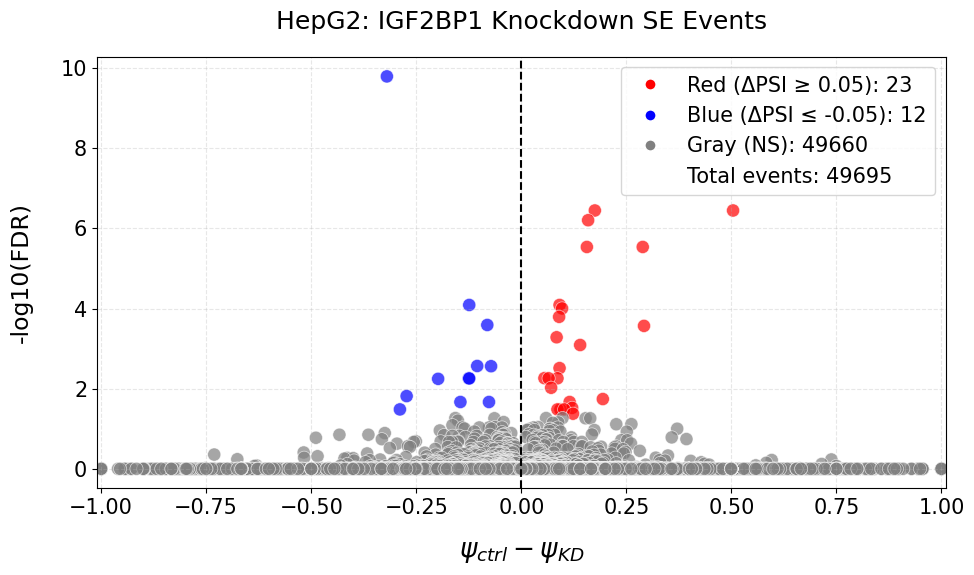

In [27]:
# Create a volcano plot


# DPSI conversion
IGF_HEPG2_filtered = IGF_HEPG2_filtered.assign(
    IncLevelDifference = IGF_HEPG2_filtered["IncLevelDifference"] * -1
)

# -log10 FDR conversion

# Find the smallest non-zero FDR value
min_nonzero_fdr = IGF_HEPG2_filtered.loc[IGF_HEPG2_filtered["FDR"] > 0, "FDR"].min()

# Replace zeros with min
IGF_HEPG2_filtered["FDR_safe"] = IGF_HEPG2_filtered["FDR"].replace(0, min_nonzero_fdr)

# Calculate -log10(FDR)
IGF_HEPG2_filtered["neg_log10_FDR"] = -np.log10(IGF_HEPG2_filtered["FDR_safe"])


# Colors and plots

IGF_HEPG2_filtered["color"] = IGF_HEPG2_filtered.apply(assign_color, axis=1)

counts = IGF_HEPG2_filtered["color"].value_counts().to_dict()
num_points = len(IGF_HEPG2_filtered)

# Parameter for global font size
plt.rcParams.update({'font.size': 15})

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    IGF_HEPG2_filtered["IncLevelDifference"],
    IGF_HEPG2_filtered["neg_log10_FDR"],
    c=IGF_HEPG2_filtered["color"],
    alpha=0.7,
    edgecolors='w',
    linewidth=0.5,
    s = 90
)

# Setting x axis
xlim = max(abs(min(IGF_HEPG2_filtered["IncLevelDifference"])), abs(max(IGF_HEPG2_filtered["IncLevelDifference"])))
plt.xlim(-xlim - 0.01, xlim + 0.01)  # symmetric around zero
plt.axvline(0, color="black", linestyle="--")  # reference line at zero

# Legend
legend_labels = [
    f"Red (ΔPSI ≥ 0.05): {counts.get('red', 0)}",
    f"Blue (ΔPSI ≤ -0.05): {counts.get('blue', 0)}",
    f"Gray (NS): {counts.get('gray', 0)}",
    f"Total events: {num_points}"
]

# Create dummy handles for legend colors
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker='o', color='w', label=legend_labels[0],
           markerfacecolor='red', markersize=8),
    Line2D([0], [0], marker='o', color='w', label=legend_labels[1],
           markerfacecolor='blue', markersize=8),
    Line2D([0], [0], marker='o', color='w', label=legend_labels[2],
           markerfacecolor='gray', markersize=8),
    Line2D([0], [0], color='w', label=legend_labels[3])  # total count (no color)
]

plt.legend(handles=handles, loc="best")

# Labels
plt.xlabel("$\\psi_{ctrl} - \\psi_{KD}$", fontsize = 19, labelpad = 15)
plt.ylabel("-log10(FDR)", fontsize = 17, labelpad = 20)
plt.title(f"HepG2: IGF2BP1 Knockdown SE Events", pad=20)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()
